### Creating data to view and fit

In [1]:
from  sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [2]:
# Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [3]:
# Check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

Visualizing our created data

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


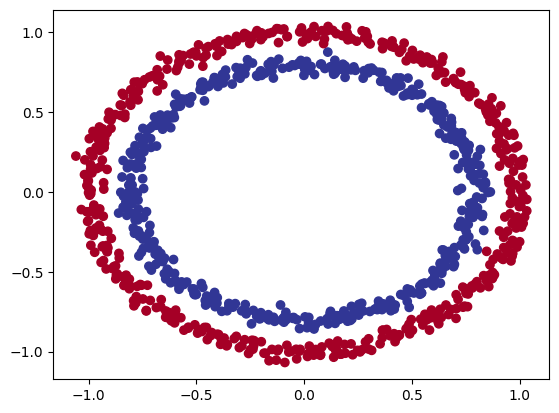

In [5]:
# Visuallize with a plot
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and output shapes

In [6]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

In [8]:
# how many samples we're working 
len(X), len(y)

(1000, 1000)

In [9]:
# View the first example of features and labels
X[5], y[5]

(array([-0.47964637,  0.67643477]), 1)

### Steps in modelling

In [10]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. Fit the model 
model_1.fit(X, y, epochs=5)



Epoch 1/5


32/32 [==============================] - 1s 1ms/step - loss: 6.1801 - accuracy: 0.4900
Epoch 2/5
32/32 [==============================] - 0s 1ms/step - loss: 6.0360 - accuracy: 0.4820
Epoch 3/5
32/32 [==============================] - 0s 1ms/step - loss: 5.8938 - accuracy: 0.4880
Epoch 4/5
32/32 [==============================] - 0s 1ms/step - loss: 4.6513 - accuracy: 0.4770
Epoch 5/5
32/32 [==============================] - 0s 1ms/step - loss: 2.9675 - accuracy: 0.4830


In [11]:
# Let's try and improve our model by training for longer
model_1.fit(X, y, epochs=200, verbose=0)

In [12]:
# Evaluation
model_1.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5000


[0.6934831142425537, 0.5]

In [13]:
# let's add extra layer

# Set the random seed
tf.random.set_seed(42)

# 1. Create a model, this time with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [14]:
# 4. Evaluate the model
model_2.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6948 - accuracy: 0.5000


[0.6947872042655945, 0.5]

### Improving our model

In [15]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
model_3.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 3.6546 - accuracy: 0.4270
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 1.1023 - accuracy: 0.4760
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7528 - accuracy: 0.5000
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7335 - accuracy: 0.5000
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7187 - accuracy: 0.5000
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7081 - accuracy: 0.5000
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7015 - accuracy: 0.5000
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6977 - accuracy: 0.5000
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6955 - accuracy: 0.5000
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6944 - accuracy: 0.5000
Epoch 11/

In [16]:
# 4. Evaluate the model
model_3.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6943 - accuracy: 0.4990


[0.6943369507789612, 0.49900001287460327]

To visualize our model's predictions, let's create a function `plot_decision_boundary()`, this function will:
* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make preditions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falss)

In [17]:
import numpy as np

In [18]:
import numpy as np 
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary created by a model predicting on X.
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multiclass classification")
        # We have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 [==============================] - 0s 1ms/step
doing binary classification


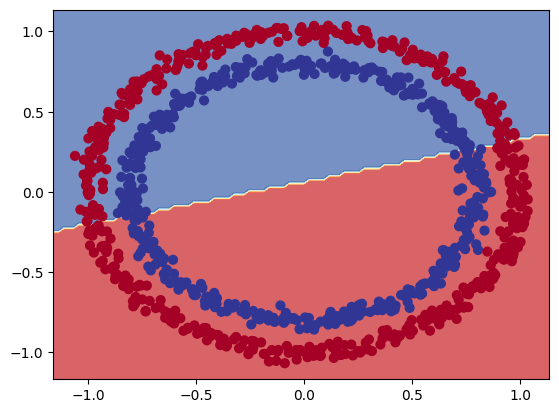

In [19]:
# Check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

### The missing piece : Non Linearity

In [20]:
# Set tje random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2978 - accuracy: 0.4190
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 4.2240 - accuracy: 0.4160
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1663 - accuracy: 0.4150
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1615 - accuracy: 0.4140
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1589 - accuracy: 0.4150
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1480 - accuracy: 0.4160
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1375 - accuracy: 0.4170
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1352 - accuracy: 0.4210
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1334 - accuracy: 0.4220
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 4.1050 - accuracy: 0.4230
Epoch 11/

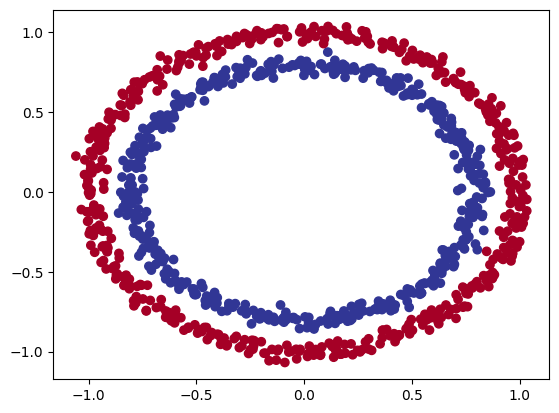

In [21]:
# Check out our data 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 [==============================] - 0s 993us/step
doing binary classification


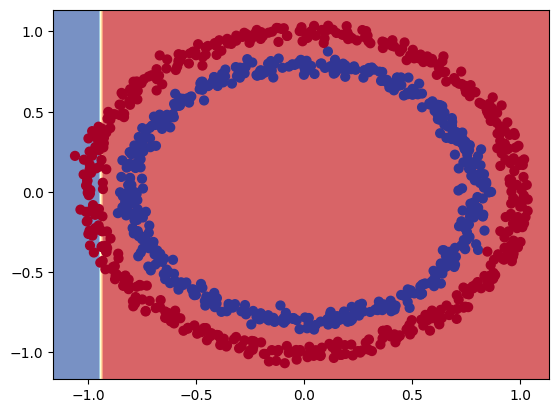

In [22]:
# Check the decision boundary for our latest model
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

### let's try build our first neural network with a non-linear activation function

In [23]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

# 2. Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0282 - accuracy: 0.4870
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9942 - accuracy: 0.4870
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9828 - accuracy: 0.4870
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9675 - accuracy: 0.4870
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9552 - accuracy: 0.4870
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9442 - accuracy: 0.4880
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9385 - accuracy: 0.4860
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9367 - accuracy: 0.4880
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9355 - accuracy: 0.4870
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9150 - accuracy: 0.4870
Epoch 11/

In [24]:
# Time to replicate the multi-layer neural network from TensorFLow playground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_6.fit(X, y, epochs=250)

Epoch 1/250
32/32 [==============================] - 1s 2ms/step - loss: 3.6828 - accuracy: 0.4640
Epoch 2/250
32/32 [==============================] - 0s 1ms/step - loss: 2.9520 - accuracy: 0.4600
Epoch 3/250
32/32 [==============================] - 0s 1ms/step - loss: 2.6985 - accuracy: 0.4620
Epoch 4/250
32/32 [==============================] - 0s 1ms/step - loss: 2.4650 - accuracy: 0.4550
Epoch 5/250
32/32 [==============================] - 0s 1ms/step - loss: 2.1105 - accuracy: 0.4610
Epoch 6/250
32/32 [==============================] - 0s 1ms/step - loss: 1.2955 - accuracy: 0.4680
Epoch 7/250
32/32 [==============================] - 0s 1ms/step - loss: 0.9369 - accuracy: 0.4660
Epoch 8/250
32/32 [==============================] - 0s 1ms/step - loss: 0.9001 - accuracy: 0.4630
Epoch 9/250
32/32 [==============================] - 0s 1ms/step - loss: 0.8776 - accuracy: 0.4610
Epoch 10/250
32/32 [==============================] - 0s 1ms/step - loss: 0.8594 - accuracy: 0.4590
Epoch 11/

In [25]:
# Evaluate the model
model_6.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.0751 - accuracy: 0.9920


[0.0750957801938057, 0.9919999837875366]

313/313 [==============================] - 0s 1ms/step
doing binary classification


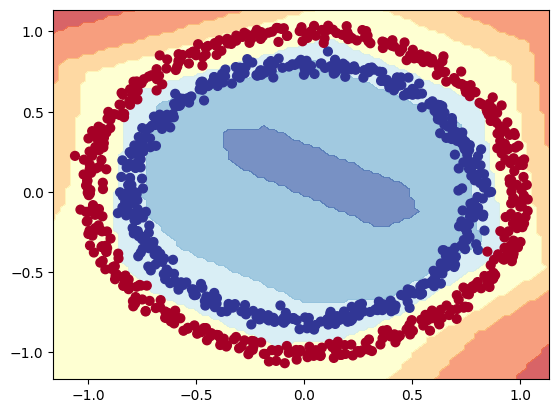

In [26]:
plot_decision_boundary(model=model_6,
                       X=X,
                       y=y)

In [27]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 1ms/step - loss: 0.6909 - accuracy: 0.5070
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6905 - accuracy: 0.5120
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6900 - accuracy: 0.5170
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6896 - accuracy: 0.5190
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6892 - accuracy: 0.5160
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6887 - accuracy: 0.5150
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6881 - accuracy: 0.5290
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6876 - accuracy: 0.5340
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6869 - accuracy: 0.5360
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6863 - accuracy: 0.5160
Epoch 11/

In [28]:
# 4. Evalute the model
model_7.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.2318 - accuracy: 0.9910


[0.2317805141210556, 0.9909999966621399]

313/313 [==============================] - 0s 1ms/step
doing binary classification


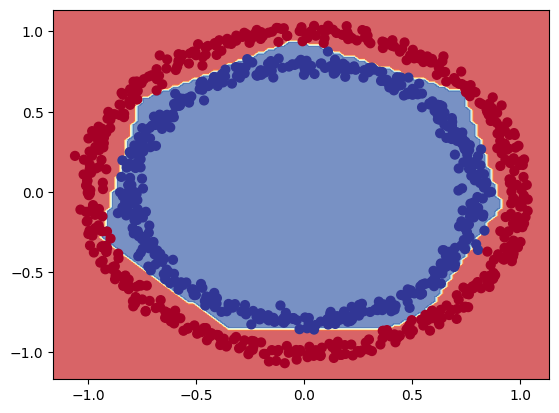

In [29]:
# Let's visualize our model_7
plot_decision_boundary(model_7, X, y)

In [30]:
# Split the dataset into train and test
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [31]:
# Let's recreate a model to fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model (same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") 
])

# 2. Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# 3. Fit the model
history = model_8.fit(X_train, y_train, epochs=25)

Epoch 1/25


25/25 [==============================] - 1s 1ms/step - loss: 0.7118 - accuracy: 0.4775
Epoch 2/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6956 - accuracy: 0.4700
Epoch 3/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6880 - accuracy: 0.4975
Epoch 4/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6840 - accuracy: 0.5475
Epoch 5/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6797 - accuracy: 0.5625
Epoch 6/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6751 - accuracy: 0.5612
Epoch 7/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6683 - accuracy: 0.5975
Epoch 8/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6632 - accuracy: 0.6025
Epoch 9/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6529 - accuracy: 0.6375
Epoch 10/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6412 - accuracy: 0.6187
Epoch 11/25
25/25 [===========

In [32]:
# 4. Evaluate the model
model_8.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.1021 - accuracy: 0.9950


[0.10206719487905502, 0.9950000047683716]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


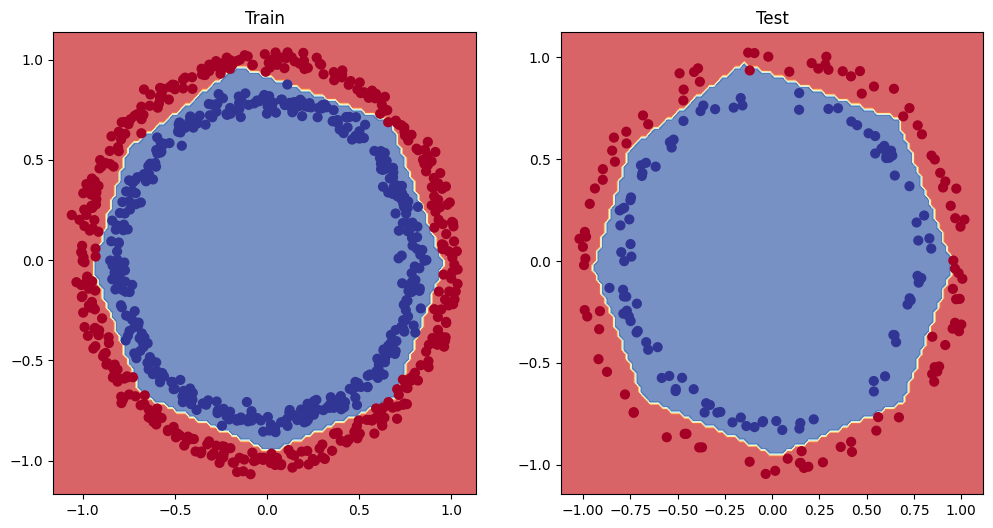

In [33]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, X_test, y_test)
plt.show()

### Plotting loss curve

In [34]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,loss,accuracy
0,0.711796,0.47750
1,0.695611,0.47000
2,0.688033,0.49750
3,0.683957,0.54750
4,0.679683,0.56250
5,0.675110,0.56125
6,0.668272,0.59750
7,0.663200,0.60250
8,0.652865,0.63750
9,0.641160,0.61875


Text(0.5, 1.0, 'Model_8 loss curves')

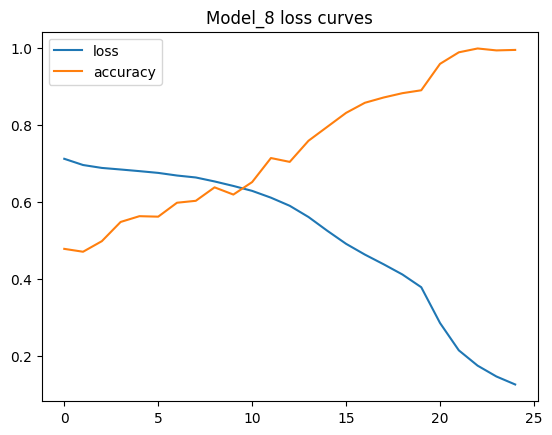

In [35]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_8 loss curves")

## Finding the best learining rate

In [36]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# 3. Fit the model (passing lr_scheduler callback)
history_9 = model_9.fit(X_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])

Epoch 1/100
25/25 [==============================] - 1s 2ms/step - loss: 0.7059 - accuracy: 0.5150 - lr: 1.0000e-04
Epoch 2/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7055 - accuracy: 0.5150 - lr: 1.1220e-04
Epoch 3/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7050 - accuracy: 0.5150 - lr: 1.2589e-04
Epoch 4/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7046 - accuracy: 0.5150 - lr: 1.4125e-04
Epoch 5/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7041 - accuracy: 0.5150 - lr: 1.5849e-04
Epoch 6/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7036 - accuracy: 0.5175 - lr: 1.7783e-04
Epoch 7/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7030 - accuracy: 0.5138 - lr: 1.9953e-04
Epoch 8/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7025 - accuracy: 0.5125 - lr: 2.2387e-04
Epoch 9/100
25/25 [==============================] - 0s 1ms/step - loss:

<Axes: xlabel='epochs'>

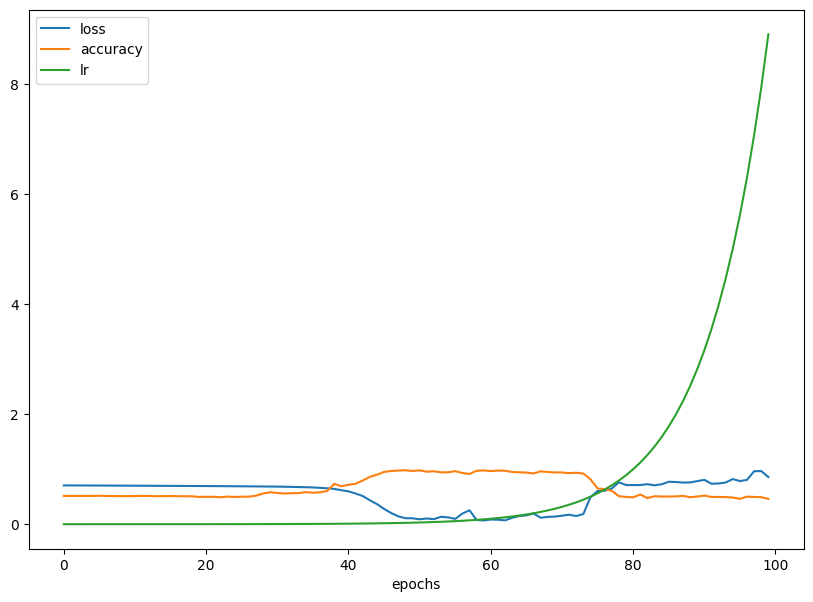

In [37]:
# Checout the history
pd.DataFrame(history_9.history).plot(figsize=(10, 7), xlabel="epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

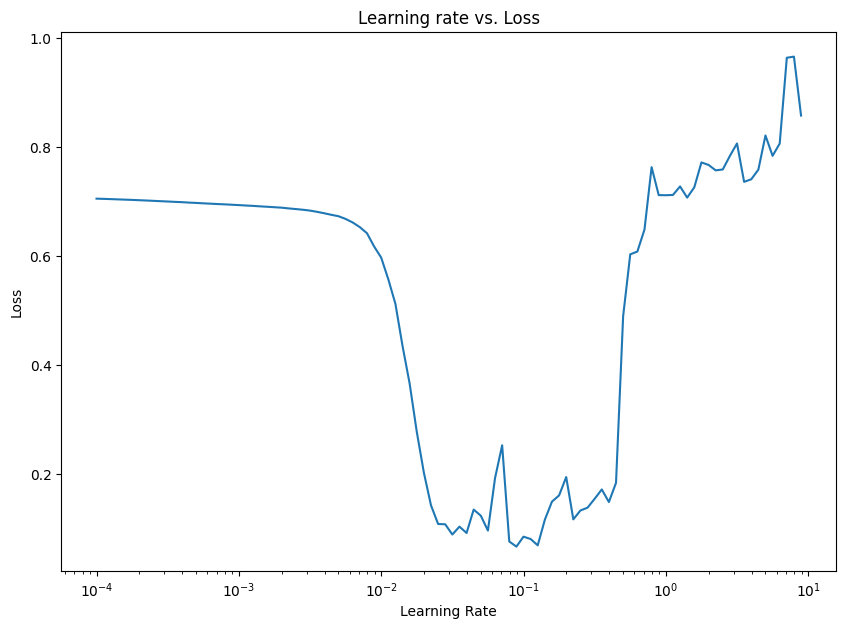

In [38]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")

In [39]:
# Let's try using a higher ideal learning rate with the same model as before

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model with the ideal learning rate
model_10.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                   metrics=["accuracy"])

# Fit the model for 20 epochs (5 less than before)
history_10 = model_10.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 [==============================] - 1s 1ms/step - loss: 0.6913 - accuracy: 0.5263
Epoch 2/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6840 - accuracy: 0.5437
Epoch 3/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6733 - accuracy: 0.6012
Epoch 4/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6369 - accuracy: 0.6513
Epoch 5/20
25/25 [==============================] - 0s 1ms/step - loss: 0.5709 - accuracy: 0.7937
Epoch 6/20
25/25 [==============================] - 0s 1ms/step - loss: 0.4479 - accuracy: 0.9438
Epoch 7/20
25/25 [==============================] - 0s 1ms/step - loss: 0.3373 - accuracy: 0.9475
Epoch 8/20
25/25 [==============================] - 0s 1ms/step - loss: 0.2490 - accuracy: 0.9712
Epoch 9/20
25/25 [==============================] - 0s 1ms/step - loss: 0.1857 - accuracy: 0.9875
Epoch 10/20
25/25 [==============================] - 0s 1ms/step - loss: 0.1418 - accuracy: 0.9912
Epoch 11/20
25/25 [

In [40]:
# 4. Evaluate model_10 on the test dataset
model_10.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.0594 - accuracy: 0.9750


[0.05942004546523094, 0.9750000238418579]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


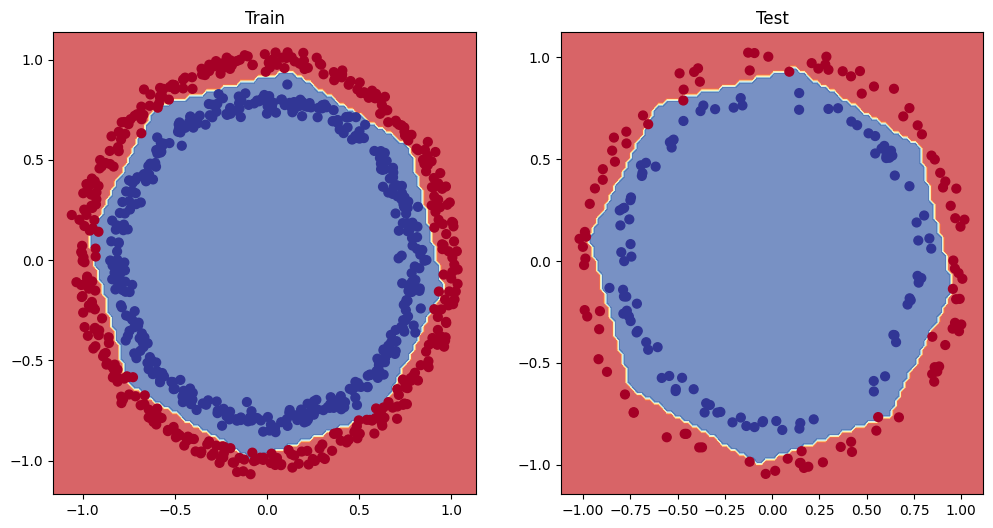

In [41]:
# plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_10, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_10, X_test, y_test)
plt.show()

In [42]:
# Check the accuracy of our model.
loss, accuracy = model_10.evaluate(X_test, y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {(accuracy*100):.2f}%")

7/7 [==============================] - 0s 2ms/step - loss: 0.0594 - accuracy: 0.9750
Model loss on the test set: 0.05942004546523094
Model accuracy on the test set: 97.50%


How about a confusion matrix?

In [43]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

# Make predictions
y_preds = model_10.predict(X_test)

# Create confusion matrix
# confusion_matrix(y_test, y_preds)

7/7 [==============================] - 0s 1ms/step


In [44]:
y_test[:10]

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 0], dtype=int64)

In [45]:
y_preds[:10]

array([[9.7381139e-01],
       [9.7381139e-01],
       [9.7258902e-01],
       [9.7381139e-01],
       [3.3046033e-02],
       [3.0541715e-01],
       [9.7365695e-01],
       [8.6712133e-04],
       [9.7381139e-01],
       [4.8236069e-03]], dtype=float32)

Looks like our predictions array has come out in prediction probability form... the standard output from the sigmoid (or softmax) activation function.

In [46]:
# Convert prediction probabilities to binary format and view the first 10
tf.round(y_preds)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [47]:
# Create a confusion matrix
confusion_matrix(y_test, tf.round(y_preds))

array([[96,  5],
       [ 0, 99]], dtype=int64)

In [48]:
# Prettify our confusion matrix

import itertools
from sklearn.metrics import confusion_matrix
figsize = (10, 10)

def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):

    # Create the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize our confusion matrix
    n_classes = cm.shape[0]

    # let's prettify it 
    fig, ax = plt.subplots(figsize=figsize)

    # Create a matrix plot
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)


    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])
        
        
    # label the axes
    ax.set(title="Confusion Matrix",
        xlabel="Predicted Label",
        ylabel="True Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels)

    # Set x-axis labels to bottom
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()

    # Adjust label size
    ax.yaxis.label.set_size(text_size)
    ax.xaxis.label.set_size(text_size)
    ax.title.set_size(text_size)

    # Set threshold for different colors
    threshold = (cm.max() + cm.min()) / 2

    # Plot the text on each cell
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size)

# Working with a larger example (multiclass classification)

When you have more than two classes as an option, it's known as **multi-class classification**.
* this means if you have 3 different classes, it's multi-class classification.
* It also means if you have 100 different classes, it's multi-class classificaiton.

In [49]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [50]:
# Show the first training example
print(f"Training sample:\n{train_data[0]}\n")
print(f"Trining label:\n{train_labels[0]}\n")

Training sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [51]:
# Check the shape of a single example
train_data[0].shape, train_labels[0].shape

((28, 28), ())

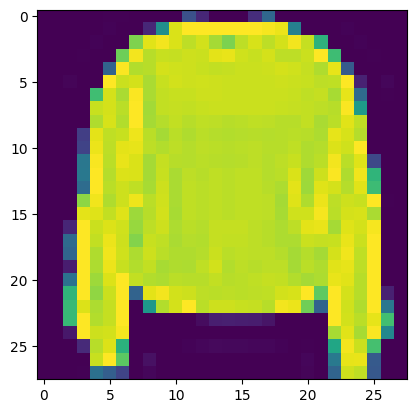

In [52]:
# Plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[7])

In [53]:
# Check out samples label
train_labels[7]

2

In [54]:
# Create a small list so we can index onto our training labels so they're human-readable
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankel boot"]

len(class_names)

10

Text(0.5, 1.0, 'Sandal')

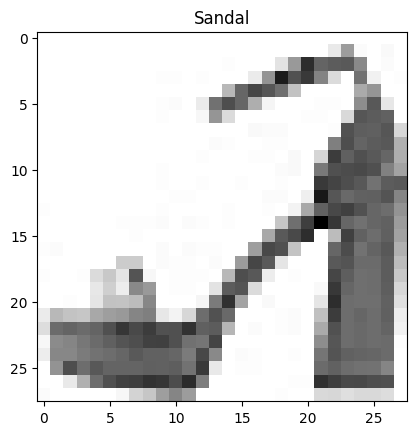

In [55]:
# Plot an example image and its label
index_of_choice = 172
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

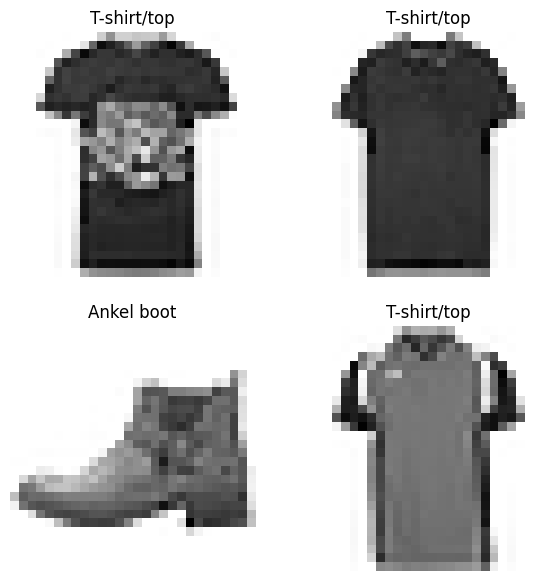

In [56]:
# Plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7, 7))
for i in range(4):
    ax = plt.subplot(2, 2, i+1)
    rand_index = random.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[rand_index]])
    plt.axis(False)

## Building a multi-class classification model

For our multi-class classification model, we can use a similar architecture to our binary classifier, however, we're going to have to tweak a few things:
* Input shape = 28 x 28 (the shape of one image)
* Output shape = 10 (one per class of clothing)
* Loss function = tf.keras.losses.CategoricalCrossentropy()
    * If your labels are one-hot encoded, use CategoricalCrossentropy()
    * If your labels are integer form use SparseCategoricalCrossentropy()
* Output layer activation = Softmax 

In [57]:
# Set random seed
tf.random.set_seed(42)

# !. Create the model
model_11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

# 2. Compile the model
model_11.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# 3. Fit the model
non_norm_history = model_11.fit(train_data, train_labels, epochs=10, validation_data=(test_data, test_labels))

Epoch 1/10
1875/1875 [==============================] - 4s 2ms/step - loss: 2.3286 - accuracy: 0.0987 - val_loss: 2.3027 - val_accuracy: 0.1000
Epoch 2/10
1875/1875 [==============================] - 3s 2ms/step - loss: 2.3028 - accuracy: 0.0984 - val_loss: 2.3027 - val_accuracy: 0.1000
Epoch 3/10
1875/1875 [==============================] - 3s 2ms/step - loss: 2.3029 - accuracy: 0.1001 - val_loss: 2.3027 - val_accuracy: 0.1000
Epoch 4/10
1875/1875 [==============================] - 3s 2ms/step - loss: 2.3028 - accuracy: 0.0975 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 5/10
1875/1875 [==============================] - 3s 2ms/step - loss: 2.3028 - accuracy: 0.0973 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 6/10
1875/1875 [==============================] - 3s 2ms/step - loss: 2.3028 - accuracy: 0.0992 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 7/10
1875/1875 [==============================] - 3s 2ms/step - loss: 2.3028 - accuracy: 0.0987 - val_loss: 2.3026 - val_accuracy:

In [58]:
# Check the model summary
model_11.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_23 (Dense)            (None, 4)                 3140      
                                                                 
 dense_24 (Dense)            (None, 4)                 20        
                                                                 
 dense_25 (Dense)            (None, 10)                50        
                                                                 
Total params: 3210 (12.54 KB)
Trainable params: 3210 (12.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [59]:
# Check the min and max values of the training data
train_data.min(), train_data.max()

(0, 255)

In [60]:
# We can get our training and testing data between 0 and 1 by dividing by the maximum
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

# Check the min and max values of the scaled training data
train_data_norm.min(), train_data_norm.max()

(0.0, 1.0)

In [61]:
# now our dat is normalized, let's build a model to find patterns in it

# Set random seed
tf.random.set_seed(42)

# 1. Create a model (same as model_11)
model_12 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_12.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# 3. Fit the model
norm_history = model_12.fit(train_data_norm, train_labels, epochs=10, validation_data=(test_data_norm, test_labels))

Epoch 1/10
1875/1875 [==============================] - 5s 2ms/step - loss: 1.2042 - accuracy: 0.5706 - val_loss: 0.8234 - val_accuracy: 0.7096
Epoch 2/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.7468 - accuracy: 0.7261 - val_loss: 0.7207 - val_accuracy: 0.7260
Epoch 3/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6748 - accuracy: 0.7405 - val_loss: 0.6856 - val_accuracy: 0.7346
Epoch 4/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6439 - accuracy: 0.7455 - val_loss: 0.6672 - val_accuracy: 0.7381
Epoch 5/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6251 - accuracy: 0.7486 - val_loss: 0.6431 - val_accuracy: 0.7430
Epoch 6/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6110 - accuracy: 0.7534 - val_loss: 0.6314 - val_accuracy: 0.7456
Epoch 7/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.5931 - accuracy: 0.7660 - val_loss: 0.6141 - val_accuracy:

<Axes: title={'center': 'Normalized Data'}>

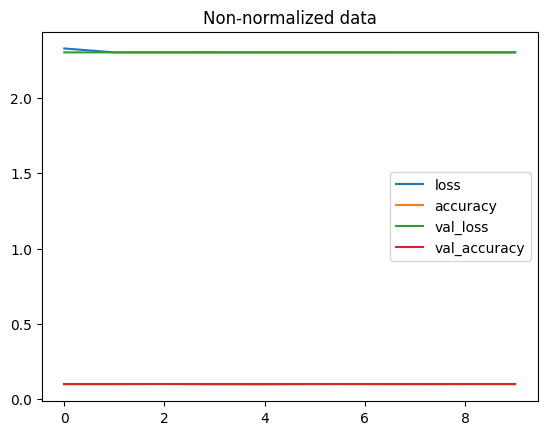

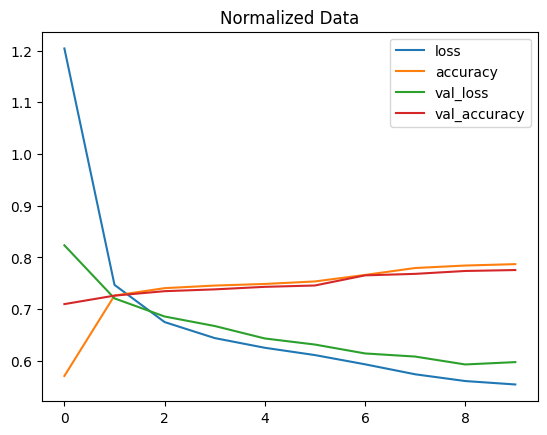

In [62]:
import pandas as pd
# Plot non-normalized data loss curves
pd.DataFrame(non_norm_history.history).plot(title="Non-normalized data")
# Plot normalized data loss curves
pd.DataFrame(norm_history.history).plot(title="Normalized Data")

## Finding the ideal learning rate

In [63]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_13.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# Create the learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/20))

# 3. Fit the model
find_lr_history = model_13.fit(train_data_norm,
                               train_labels,
                               epochs=40,validation_data=(test_data_norm, test_labels),
                               callbacks=[lr_scheduler])

Epoch 1/40
1875/1875 [==============================] - 4s 2ms/step - loss: 1.3917 - accuracy: 0.4509 - val_loss: 1.0794 - val_accuracy: 0.6129 - lr: 0.0010
Epoch 2/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.9830 - accuracy: 0.6448 - val_loss: 0.9397 - val_accuracy: 0.6719 - lr: 0.0011
Epoch 3/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.8868 - accuracy: 0.6858 - val_loss: 0.8764 - val_accuracy: 0.6955 - lr: 0.0013
Epoch 4/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.8424 - accuracy: 0.6957 - val_loss: 0.8500 - val_accuracy: 0.7092 - lr: 0.0014
Epoch 5/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.8236 - accuracy: 0.7031 - val_loss: 0.8301 - val_accuracy: 0.7071 - lr: 0.0016
Epoch 6/40
1875/1875 [==============================] - 3s 2ms/step - loss: 0.8062 - accuracy: 0.7044 - val_loss: 0.8213 - val_accuracy: 0.7061 - lr: 0.0018
Epoch 7/40
1875/1875 [==============================] - 3s

Text(0.5, 1.0, 'Finding the ideal learning rate')

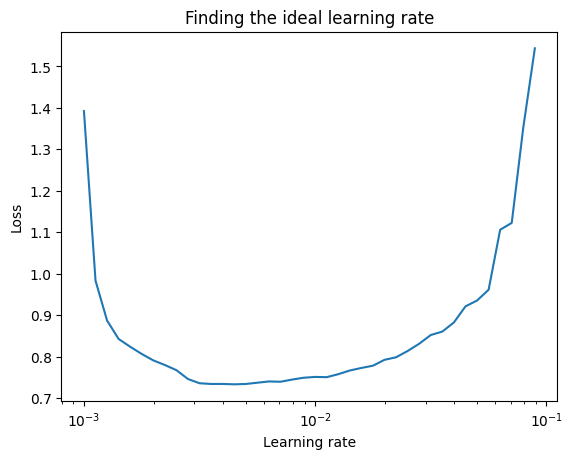

In [64]:
# plot the learning rate decay curve
import numpy as np
import matplotlib.pyplot as plt 

lrs = 1e-3 * (10**(tf.range(40)/20))
plt.semilogx(lrs, find_lr_history.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate")

In [65]:
# let's refit a model with the ideal learning rate

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_14 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2. Compile the model
model_14.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                 metrics=["accuracy"])

# 3. fit the model
history_14 = model_14.fit(train_data_norm,
                          train_labels,
                          epochs=20,
                          validation_data=(test_data_norm, test_labels))

Epoch 1/20
1875/1875 [==============================] - 4s 2ms/step - loss: 1.3308 - accuracy: 0.5191 - val_loss: 0.9060 - val_accuracy: 0.6687
Epoch 2/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.8440 - accuracy: 0.6868 - val_loss: 0.8163 - val_accuracy: 0.6961
Epoch 3/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.7851 - accuracy: 0.7116 - val_loss: 0.7874 - val_accuracy: 0.7080
Epoch 4/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.7493 - accuracy: 0.7278 - val_loss: 0.7565 - val_accuracy: 0.7322
Epoch 5/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.7232 - accuracy: 0.7401 - val_loss: 0.7426 - val_accuracy: 0.7428
Epoch 6/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.7003 - accuracy: 0.7477 - val_loss: 0.7300 - val_accuracy: 0.7387
Epoch 7/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6803 - accuracy: 0.7557 - val_loss: 0.7080 - val_accuracy:

### Evaluating our multi-class classification model

To evaluate our multi-class classification model we could:
* Evaluate its performance using other classification metrics (such as confusion matrix)
* Assess some of its predictions (through visualizations)
* Improve its results (by training it for longer or changing the architecture)
* Save and export if for use in an application


In [66]:
# Create a confusion matrix


def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):

    # Create the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize our confusion matrix
    n_classes = cm.shape[0]

    # let's prettify it 
    fig, ax = plt.subplots(figsize=figsize)

    # Create a matrix plot
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)


    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])
        
        
    # label the axes
    ax.set(title="Confusion Matrix",
        xlabel="Predicted Label",
        ylabel="True Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels)

    # Set x-axis labels to bottom
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()

    # Adjust label size
    ax.yaxis.label.set_size(text_size)
    ax.xaxis.label.set_size(text_size)
    ax.title.set_size(text_size)

    # Set threshold for different colors
    threshold = (cm.max() + cm.min()) / 2

    # Plot the text on each cell
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size)

In [67]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankel boot']

In [68]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [69]:
# Make some predictions  with our model
y_probs = model_14.predict(test_data_norm)

# View the first 5 predictions
y_probs[:5]

  1/313 [..............................] - ETA: 26s

313/313 [==============================] - 0s 1ms/step


array([[5.5009559e-07, 3.5433476e-11, 2.8928906e-14, 1.9367510e-09,
        4.8445351e-13, 2.9831657e-01, 2.4627020e-06, 9.9895142e-02,
        1.3746779e-03, 6.0041064e-01],
       [4.1492359e-04, 3.7291145e-10, 7.8157037e-01, 7.9727274e-09,
        2.3782950e-02, 1.2854485e-13, 1.8454218e-01, 0.0000000e+00,
        9.6896272e-03, 2.5051991e-22],
       [5.4811560e-09, 9.9810189e-01, 8.5092790e-07, 8.7794775e-05,
        1.8086246e-03, 2.8268340e-16, 8.4322841e-07, 5.1063140e-30,
        3.2634749e-11, 4.1738849e-17],
       [1.2357498e-07, 9.9706894e-01, 1.4913431e-06, 1.8164850e-03,
        1.1098136e-03, 2.2510329e-13, 3.0630474e-06, 2.5343417e-22,
        3.1806582e-10, 6.6186531e-13],
       [3.0163676e-01, 6.7973313e-05, 1.3801691e-01, 3.5002328e-02,
        2.7713686e-02, 2.1042879e-05, 4.7973484e-01, 7.7457598e-12,
        1.7805940e-02, 5.3159403e-07]], dtype=float32)

> Note : Remember to make predictions on the same kind of data your model was trained on normalized data.

In [70]:
y_probs[0], tf.argmax(y_probs[0]), class_names[tf.argmax(y_probs[0])]

(array([5.5009559e-07, 3.5433476e-11, 2.8928906e-14, 1.9367510e-09,
        4.8445351e-13, 2.9831657e-01, 2.4627020e-06, 9.9895142e-02,
        1.3746779e-03, 6.0041064e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=9>,
 'Ankel boot')

In [71]:
# Convert all of the prediction probabilities into integers
y_preds = y_probs.argmax(axis=1)

# View the first 10 prediction labels
y_preds[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=int64)

In [72]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [73]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true=test_labels,
                 y_pred=y_preds)

array([[726,   0,   3, 103,   4,   0, 140,   5,  19,   0],
       [  1, 932,   0,  47,  14,   0,   6,   0,   0,   0],
       [ 19,   3, 419,  22, 197,   0, 334,   0,   6,   0],
       [ 55,  11,   0, 836,  32,   0,  65,   1,   0,   0],
       [  3,   4, 114,  39, 716,   0, 121,   0,   3,   0],
       [  1,   0,   0,   1,   0, 898,   0,  42,  13,  45],
       [202,   1, 131,  68, 112,   0, 465,   1,  20,   0],
       [  2,   0,   0,   0,   0,  45,   0, 923,   2,  28],
       [ 37,   0,  13,   5,   2,   4,  23,   6, 910,   0],
       [  6,   0,   0,   1,   0,  16,   0,  48,   1, 928]], dtype=int64)

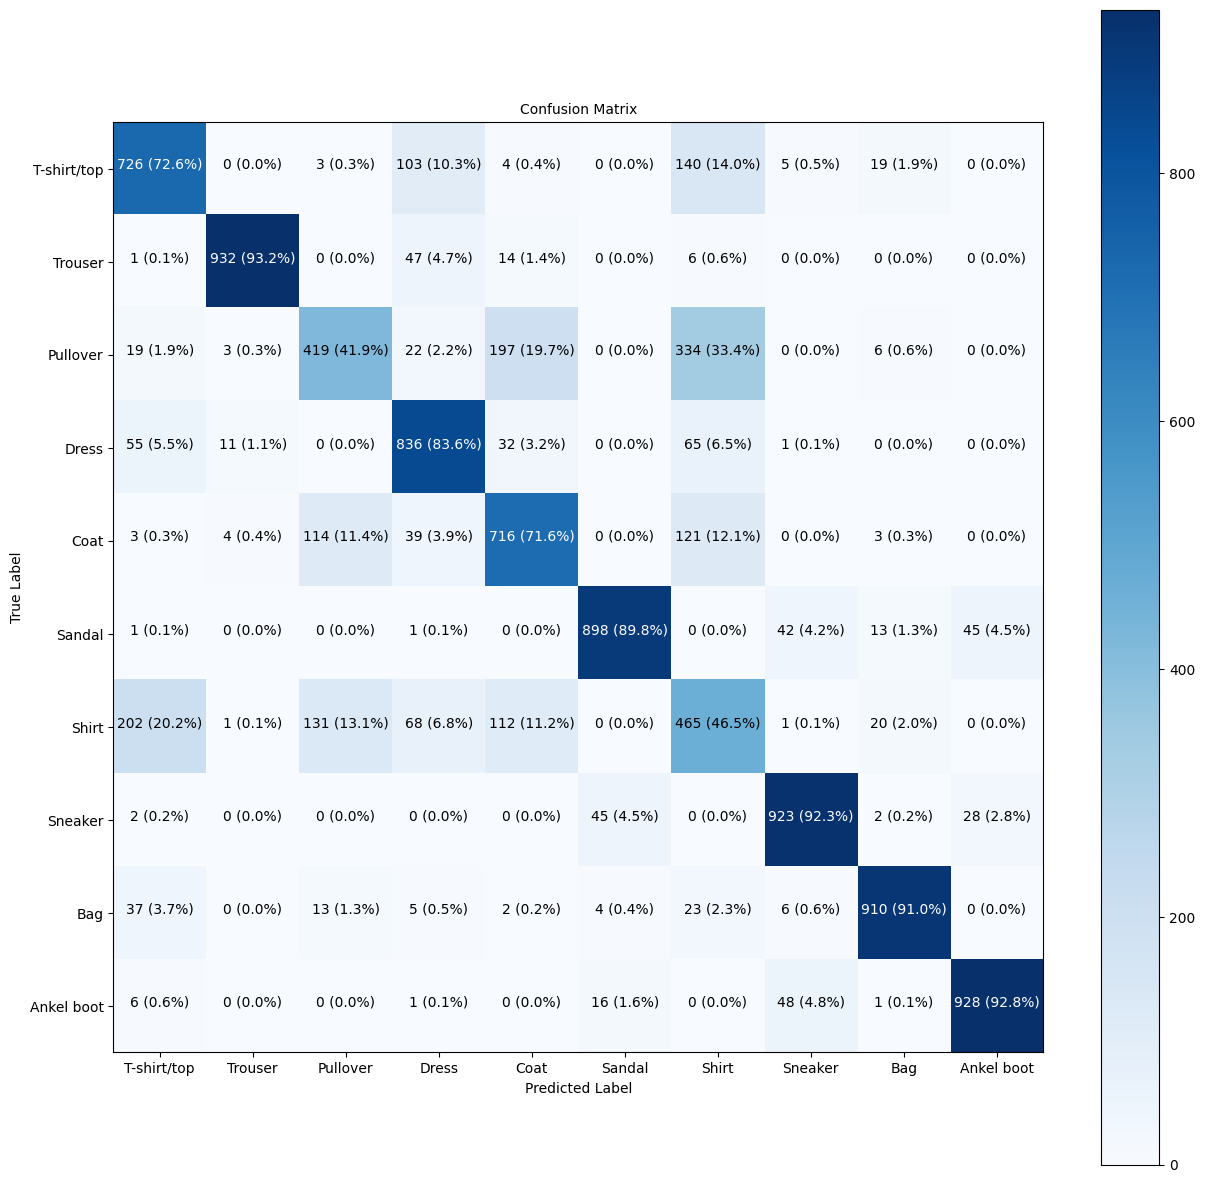

In [74]:
# Make a prettier confusion matrix
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_names,
                      figsize=(15, 15),
                      text_size=10)

In [75]:
# Plotting random image

import random

def plot_random_image(model, images, true_labels, classes):
    """
    Picks a random image, plots it and labels it with a prediction and truth label.
        
    """
    
    # Set up random integer
    i = random.randint(0, len(images)) 
    
    
    # Create predictions and targets
    target_image = images[i]
    pred_probs = model.predict(target_image.reshape(1, 28, 28))
    pred_label = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]
    
    # Plot the image
    plt.imshow(target_image, cmap=plt.cm.binary)
    
    # Change the color of the titles depending on if the prediction is right or wrong
    if pred_label == true_label:
        color = "green"
    else:
        color = "red"
        
    # Add xlabel information (prediction/true label)
    plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                     100*tf.reduce_max(pred_probs),
                                                     true_label),
               color=color) # Set the color to green or red based on if prediction is right or wrong

1/1 [==============================] - 0s 49ms/step


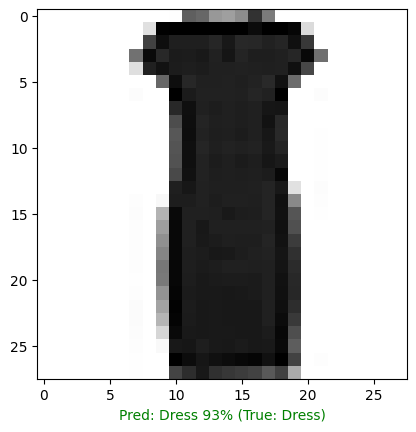

In [76]:
# Check out a random image as well as its prediction
plot_random_image(model=model_14,
                  images=test_data_norm,
                  true_labels=test_labels, 
                  classes=class_names)

### What patterns is our model learning?

In [77]:
# Find the layers of our most recent model
model_14.layers

In [78]:
# Extract a particular layer
model_14.layers[1]

In [79]:
# Get the patterns of a layer in our network
weights, biases = model_14.layers[1].get_weights()

# Shapes
weights, weights.shape

(array([[-0.8116698 , -0.3778083 , -0.42970005,  0.79341793],
        [-0.09033594, -0.59768105, -1.0560517 ,  0.5057286 ],
        [-0.640712  , -1.1393186 , -0.06669783,  0.9422106 ],
        ...,
        [-0.01817588,  0.6155221 , -0.6870914 , -0.37110847],
        [-0.6184709 ,  0.31315628, -1.2006508 ,  0.5274098 ],
        [-1.1165864 , -0.19283411, -0.13957883,  0.9743828 ]],
       dtype=float32),
 (784, 4))

In [80]:
model_14.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_32 (Dense)            (None, 4)                 3140      
                                                                 
 dense_33 (Dense)            (None, 4)                 20        
                                                                 
 dense_34 (Dense)            (None, 10)                50        
                                                                 
Total params: 3210 (12.54 KB)
Trainable params: 3210 (12.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [81]:
# Bias vector
biases, biases.shape

(array([-0.61766154,  3.209146  ,  2.1452794 , -0.46201932], dtype=float32),
 (4,))

The bias vector dictates how much the patterns within the corresponding weights matrix should influence the next layer.

In [82]:
model_14.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_32 (Dense)            (None, 4)                 3140      
                                                                 
 dense_33 (Dense)            (None, 4)                 20        
                                                                 
 dense_34 (Dense)            (None, 10)                50        
                                                                 
Total params: 3210 (12.54 KB)
Trainable params: 3210 (12.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


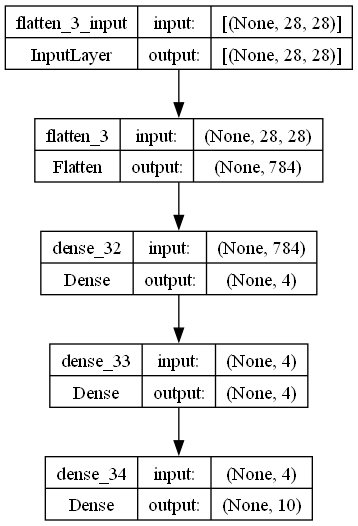

In [83]:
# let's check out another way of viewing our deep learning models
from tensorflow.keras.utils import plot_model

# See the inputs and outputs of each layer
plot_model(model_14, show_shapes=True)